# LUNA16 v3 — Backbone Swap to DenseNet-121
**DenseNet-121 · Focal Loss · MixUp · TTA · same data as v2**

Single variable changed vs v2: **the backbone**.
- v2: ResNet-50 + CBAM (24.0 M params)
- v3: **DenseNet-121** (8.0 M params, 3× smaller)

All other components identical — same train/val/test, same loss, same augmentation,
same schedule, same inference protocol — so any difference in test metrics is
attributable to the architecture itself.


## 1 · Imports & Configuration

In [1]:
import os, sys, time, json, random
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve,
)
from PIL import Image

random.seed(42); np.random.seed(42); torch.manual_seed(42)

PATCH_DIR = Path("luna16_patches")
MODEL_DIR = Path("model_luna16_v3"); MODEL_DIR.mkdir(exist_ok=True)
OUT_DIR   = Path("luna16_output_v3");  OUT_DIR.mkdir(exist_ok=True)

CLASS_NAMES = ["non_nodule", "nodule"]
NUM_CLASSES = 2
IMG_SIZE    = 224
BATCH_SIZE  = 64
NUM_EPOCHS  = 25
LR_MAX      = 5e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP   = 1.0
EARLY_STOP_PAT = 8
FOCAL_ALPHA = 0.25
FOCAL_GAMMA = 2.0
MIXUP_ALPHA = 0.4
MIXUP_PROB  = 0.5

device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = device.type == "cuda"
print(f"PyTorch: {torch.__version__}  Device: {device}")


PyTorch: 2.6.0+cu124  Device: cuda


## 2 · DenseNet-121 Model

In [2]:
class DenseNet121Classifier(nn.Module):
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()
        b = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        self.features = b.features          # all dense blocks
        self.relu     = nn.ReLU(inplace=True)
        self.pool     = nn.AdaptiveAvgPool2d(1)
        in_f          = b.classifier.in_features   # 1024 for densenet121
        self.head     = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(in_f),
            nn.Dropout(dropout),
            nn.Linear(in_f, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.relu(x)
        x = self.pool(x)
        return self.head(x)

model = DenseNet121Classifier(NUM_CLASSES, dropout=0.4).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model: DenseNet-121     params: {n_params:,}")


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\PC/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth


  0%|          | 0.00/30.8M [00:00<?, ?B/s]

  0%|          | 128k/30.8M [00:00<00:31, 1.03MB/s]

  2%|▏         | 640k/30.8M [00:00<00:10, 3.05MB/s]

  4%|▍         | 1.38M/30.8M [00:00<00:06, 4.98MB/s]

...

 91%|█████████ | 28.0M/30.8M [00:04<00:00, 8.45MB/s]

 94%|█████████▎| 28.9M/30.8M [00:04<00:00, 8.07MB/s]

 97%|█████████▋| 30.0M/30.8M [00:04<00:00, 8.46MB/s]

100%|██████████| 30.8M/30.8M [00:04<00:00, 7.21MB/s]

Model: DenseNet-121     params: 6,957,954


## 3 · Focal Loss (same as v2)

In [3]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, reduction='none')
        pt = torch.exp(-ce)
        return (self.alpha * (1 - pt) ** self.gamma * ce).mean()

criterion = FocalLoss(FOCAL_ALPHA, FOCAL_GAMMA)
print(f"Focal Loss  α={FOCAL_ALPHA}  γ={FOCAL_GAMMA}")


Focal Loss  α=0.25  γ=2.0


## 4 · Datasets, Transforms, Loaders (same as v2)

In [4]:
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE+16, IMG_SIZE+16)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.12)),
])
eval_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = datasets.ImageFolder(PATCH_DIR/"train", transform=train_tf)
val_ds   = datasets.ImageFolder(PATCH_DIR/"val",   transform=eval_tf)
test_ds  = datasets.ImageFolder(PATCH_DIR/"test",  transform=eval_tf)

train_labels = [y for _, y in train_ds.samples]
counts_tr    = np.bincount(train_labels, minlength=NUM_CLASSES).astype(float)
w_cls        = 1.0 / (counts_tr + 1e-8)
sampler      = WeightedRandomSampler([w_cls[l] for l in train_labels],
                                      num_samples=len(train_labels), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=USE_AMP)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,  num_workers=0, pin_memory=USE_AMP)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,  num_workers=0, pin_memory=USE_AMP)

print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")


Train: 1407  Val: 866  Test: 662


## 5 · Optimizer & OneCycleLR (same as v2)

In [5]:
optimizer = optim.AdamW(model.parameters(), lr=LR_MAX/25, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR_MAX,
    steps_per_epoch=len(train_loader), epochs=NUM_EPOCHS,
    pct_start=0.3, anneal_strategy="cos", div_factor=25, final_div_factor=1e4)
scaler = GradScaler('cuda', enabled=USE_AMP)
print("Ready.")


Ready.


## 6 · Training Loop (Focal + MixUp + Early Stop, same as v2)

In [6]:
def mixup(x, y, alpha=MIXUP_ALPHA):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

def compute(y_true, y_pred, y_score=None):
    return (accuracy_score(y_true, y_pred),
            precision_score(y_true, y_pred, pos_label=1, zero_division=0),
            recall_score(y_true, y_pred, pos_label=1, zero_division=0),
            f1_score(y_true, y_pred, pos_label=1, zero_division=0),
            roc_auc_score(y_true, y_score) if y_score is not None else None)

def train_epoch():
    model.train(); rl, yp, yt = 0.0, [], []
    for imgs, lbs in train_loader:
        imgs, lbs = imgs.to(device), lbs.to(device)
        use_mix = np.random.rand() < MIXUP_PROB
        if use_mix:
            imgs, ya, yb, lam = mixup(imgs, lbs)
        optimizer.zero_grad()
        with autocast('cuda', enabled=USE_AMP):
            out = model(imgs)
            if use_mix:
                loss = lam*criterion(out, ya) + (1-lam)*criterion(out, yb)
            else:
                loss = criterion(out, lbs)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer); scaler.update(); scheduler.step()
        rl += loss.item()*imgs.size(0)
        yp.extend(out.argmax(1).cpu().numpy())
        yt.extend((ya if use_mix else lbs).cpu().numpy())
    return rl/len(train_loader.dataset), *compute(yt, yp)[:4]

@torch.no_grad()
def evaluate(loader):
    model.eval(); rl, yp, yt, ys = 0.0, [], [], []
    for imgs, lbs in loader:
        imgs, lbs = imgs.to(device), lbs.to(device)
        with autocast('cuda', enabled=USE_AMP):
            out = model(imgs); loss = criterion(out, lbs)
        rl += loss.item()*imgs.size(0)
        probs = torch.softmax(out.float(), dim=1)[:, 1]
        yp.extend(out.argmax(1).cpu().numpy())
        ys.extend(probs.cpu().numpy())
        yt.extend(lbs.cpu().numpy())
    return rl/len(loader.dataset), np.array(yt), np.array(yp), np.array(ys)

history = {k: [] for k in ["train_loss","val_loss","train_acc","val_acc",
                            "train_f1","val_f1","val_prec","val_rec","val_auc"]}
best_f1, early_ctr = 0.0, 0
best_ckpt = MODEL_DIR / "best_densenet121.pth"

print(f"{'Ep':>3} {'TrLoss':>7} {'TrAcc':>6} {'TrF1':>6} {'VaLoss':>7} "
      f"{'VaAcc':>6} {'VaF1':>6} {'VaP':>6} {'VaR':>6} {'AUC':>6} {'LR':>8} {'s':>4}")
print("-"*96)

for ep in range(1, NUM_EPOCHS+1):
    t0 = time.time()
    tr_loss, tr_acc, tr_p, tr_r, tr_f1 = train_epoch()
    va_loss, vy, vp, vs = evaluate(val_loader)
    va_acc, va_p, va_r, va_f1, va_auc = compute(vy, vp, vs)
    dt = time.time()-t0
    lr = optimizer.param_groups[0]["lr"]
    for k, v in [("train_loss",tr_loss),("val_loss",va_loss),
                  ("train_acc",tr_acc),("val_acc",va_acc),
                  ("train_f1",tr_f1),("val_f1",va_f1),
                  ("val_prec",va_p),("val_rec",va_r),("val_auc",va_auc)]:
        history[k].append(v)
    print(f"{ep:>3} {tr_loss:>7.4f} {tr_acc*100:>5.1f}% {tr_f1:.4f} "
          f"{va_loss:>7.4f} {va_acc*100:>5.1f}% {va_f1:.4f} "
          f"{va_p:.4f} {va_r:.4f} {va_auc:.4f} {lr:.2e} {dt:>3.0f}s")
    if va_f1 > best_f1:
        best_f1 = va_f1; early_ctr = 0
        torch.save({"epoch": ep, "backbone": "densenet121",
                     "model_state_dict": model.state_dict(),
                     "val_f1": va_f1, "val_auc": va_auc}, best_ckpt)
        print(f"    [*] best saved  val_f1={va_f1:.4f}  val_auc={va_auc:.4f}")
    else:
        early_ctr += 1
        if early_ctr >= EARLY_STOP_PAT:
            print(f"\nEarly stop at epoch {ep}"); break

(OUT_DIR/"history.json").write_text(json.dumps(history, indent=2))
print(f"\nTraining complete. Best val_f1 = {best_f1:.4f}")


 Ep  TrLoss  TrAcc   TrF1  VaLoss  VaAcc   VaF1    VaP    VaR    AUC       LR    s
------------------------------------------------------------------------------------------------


  1  0.0660  54.2% 0.5467  0.0429  67.2% 0.7945 0.7732 0.8170 0.5066 4.10e-05  22s
    [*] best saved  val_f1=0.7945  val_auc=0.5066


  2  0.0549  58.8% 0.5760  0.0422  66.6% 0.7726 0.8197 0.7307 0.6297 1.00e-04  13s


  3  0.0455  64.3% 0.6514  0.0375  72.2% 0.7935 0.9354 0.6890 0.8376 1.88e-04  12s


  4  0.0366  72.6% 0.7187  0.0718  64.5% 0.7107 0.9692 0.5610 0.9082 2.88e-04  13s


...

 21  0.0146  89.4% 0.8891  0.0090  95.4% 0.9708 0.9540 0.9881 0.9805 6.04e-05  19s
    [*] best saved  val_f1=0.9708  val_auc=0.9805


 22  0.0102  90.5% 0.9058  0.0088  95.5% 0.9713 0.9594 0.9836 0.9816 3.44e-05  16s
    [*] best saved  val_f1=0.9713  val_auc=0.9816


 23  0.0165  84.6% 0.8466  0.0087  95.6% 0.9721 0.9581 0.9866 0.9819 1.52e-05  16s
    [*] best saved  val_f1=0.9721  val_auc=0.9819


 24  0.0213  84.4% 0.8381  0.0091  95.2% 0.9693 0.9513 0.9881 0.9819 3.66e-06  16s


 25  0.0148  79.4% 0.7892  0.0087  95.4% 0.9707 0.9553 0.9866 0.9822 1.03e-08  18s

Training complete. Best val_f1 = 0.9721


## 7 · Training Curves

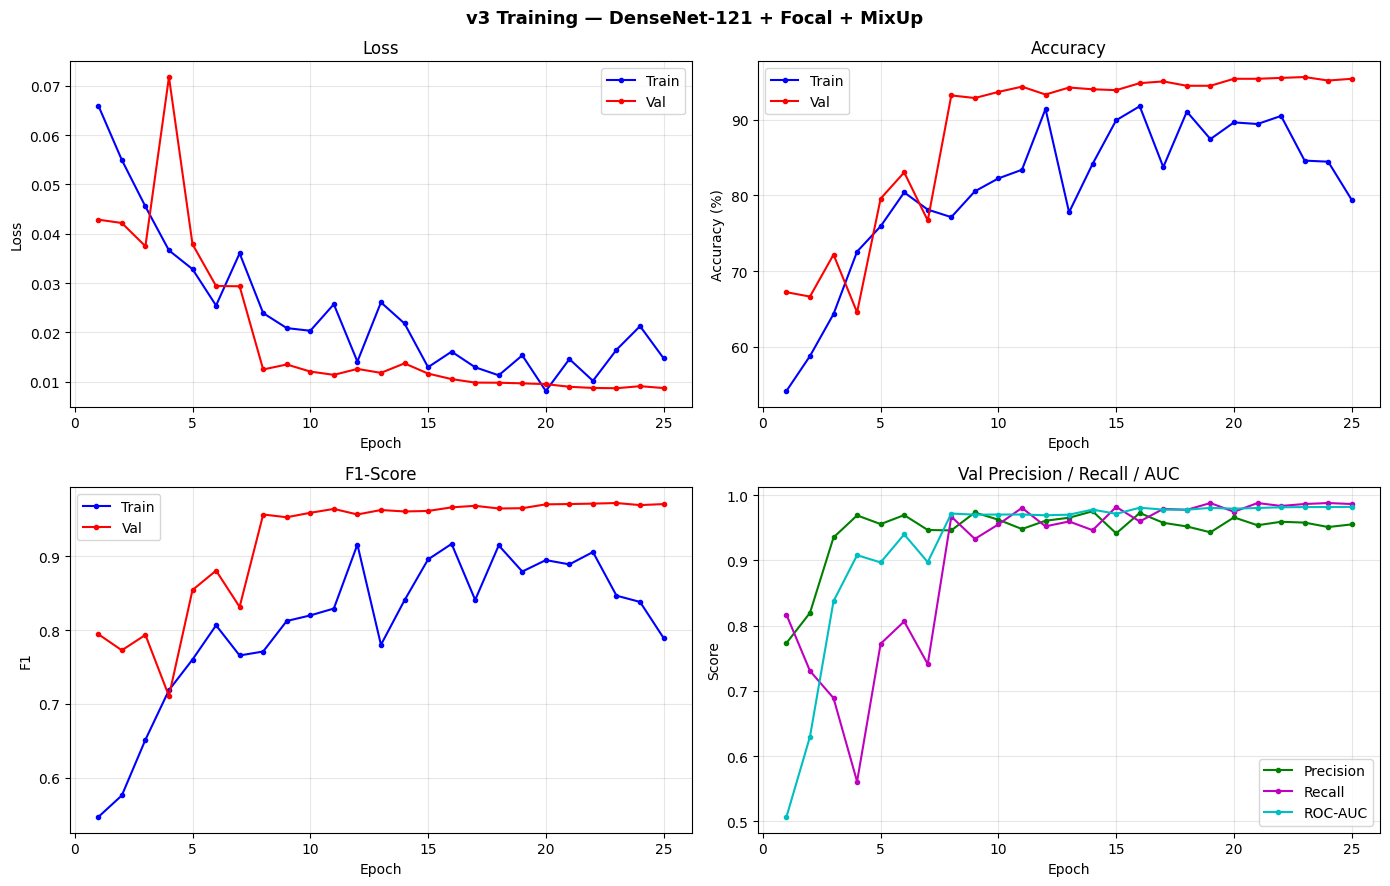

Peak train acc: 91.76%   Peak val acc: 95.61%   Δ = -3.86%
Peak train F1 : 0.9168    Peak val F1 : 0.9721    Δ = -0.0554
Diagnosis: Healthy — val ≥ train (typical with MixUp regularization)


In [7]:
eps = range(1, len(history["train_loss"])+1)
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("v3 Training — DenseNet-121 + Focal + MixUp", fontsize=13, fontweight="bold")
ax[0,0].plot(eps, history["train_loss"], "b-o", ms=3, label="Train")
ax[0,0].plot(eps, history["val_loss"],   "r-o", ms=3, label="Val")
ax[0,0].set(title="Loss", xlabel="Epoch", ylabel="Loss"); ax[0,0].legend(); ax[0,0].grid(alpha=0.3)
ax[0,1].plot(eps, [v*100 for v in history["train_acc"]], "b-o", ms=3, label="Train")
ax[0,1].plot(eps, [v*100 for v in history["val_acc"]],   "r-o", ms=3, label="Val")
ax[0,1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy (%)"); ax[0,1].legend(); ax[0,1].grid(alpha=0.3)
ax[1,0].plot(eps, history["train_f1"], "b-o", ms=3, label="Train")
ax[1,0].plot(eps, history["val_f1"],   "r-o", ms=3, label="Val")
ax[1,0].set(title="F1-Score", xlabel="Epoch", ylabel="F1"); ax[1,0].legend(); ax[1,0].grid(alpha=0.3)
ax[1,1].plot(eps, history["val_prec"], "g-o", ms=3, label="Precision")
ax[1,1].plot(eps, history["val_rec"],  "m-o", ms=3, label="Recall")
ax[1,1].plot(eps, history["val_auc"],  "c-o", ms=3, label="ROC-AUC")
ax[1,1].set(title="Val Precision / Recall / AUC", xlabel="Epoch", ylabel="Score")
ax[1,1].legend(); ax[1,1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Overfitting / underfitting check
peak_train_acc = max(history['train_acc'])*100
peak_val_acc   = max(history['val_acc'])*100
peak_train_f1  = max(history['train_f1'])
peak_val_f1    = max(history['val_f1'])
acc_gap        = peak_train_acc - peak_val_acc
f1_gap         = peak_train_f1  - peak_val_f1
print(f"Peak train acc: {peak_train_acc:.2f}%   Peak val acc: {peak_val_acc:.2f}%   Δ = {acc_gap:+.2f}%")
print(f"Peak train F1 : {peak_train_f1:.4f}    Peak val F1 : {peak_val_f1:.4f}    Δ = {f1_gap:+.4f}")
if acc_gap > 10 or f1_gap > 0.08:
    diag = "WARNING: possible overfitting"
elif peak_val_acc < 80:
    diag = "WARNING: possible underfitting"
elif acc_gap < 0:
    diag = "Healthy — val ≥ train (typical with MixUp regularization)"
else:
    diag = "Healthy fit"
print(f"Diagnosis: {diag}")


## 8 · Test-Time Augmentation Inference

In [8]:
ck = torch.load(best_ckpt, map_location=device)
model.load_state_dict(ck["model_state_dict"])
model.eval()
print(f"Loaded best — epoch {ck['epoch']}  val_f1={ck['val_f1']:.4f}  val_auc={ck['val_auc']:.4f}")

@torch.no_grad()
def tta_infer(loader):
    ys, ss = [], []
    for imgs, lbs in loader:
        imgs = imgs.to(device)
        views = [imgs,
                 torch.flip(imgs, [3]), torch.flip(imgs, [2]),
                 torch.rot90(imgs, 1, [2,3]), torch.rot90(imgs, 3, [2,3])]
        all_p = []
        for v in views:
            with autocast('cuda', enabled=USE_AMP):
                out = model(v)
            all_p.append(torch.softmax(out.float(), dim=1)[:, 1])
        probs = torch.stack(all_p).mean(0)
        ss.extend(probs.cpu().numpy()); ys.extend(lbs.numpy())
    return np.array(ys), np.array(ss)

@torch.no_grad()
def single_infer(loader):
    ys, ss = [], []
    for imgs, lbs in loader:
        imgs = imgs.to(device)
        with autocast('cuda', enabled=USE_AMP):
            out = model(imgs)
        probs = torch.softmax(out.float(), dim=1)[:, 1]
        ss.extend(probs.cpu().numpy()); ys.extend(lbs.numpy())
    return np.array(ys), np.array(ss)

ty_s, ts_s = single_infer(test_loader)
ty_t, ts_t = tta_infer(test_loader)
print("Inference (single + TTA) complete.")


Loaded best — epoch 23  val_f1=0.9721  val_auc=0.9819


Inference (single + TTA) complete.


## 9 · Comprehensive Test Metrics — Single vs TTA

In [9]:
def full_metrics(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return {
        "accuracy":     float(accuracy_score(y_true, y_pred)),
        "balanced_acc": float(balanced_accuracy_score(y_true, y_pred)),
        "precision":    float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "recall":       float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "specificity":  float(tn/(tn+fp)) if (tn+fp) else 0.0,
        "f1":           float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "mcc":          float(matthews_corrcoef(y_true, y_pred)),
        "roc_auc":      float(roc_auc_score(y_true, y_score)),
        "pr_auc":       float(average_precision_score(y_true, y_score)),
        "confusion":    {"TP":int(tp),"FP":int(fp),"TN":int(tn),"FN":int(fn)},
    }

m_single = full_metrics(ty_s, ts_s, 0.5)
m_tta    = full_metrics(ty_t, ts_t, 0.5)

print("="*72)
print(f"  {'Metric':<20} {'Single':>14} {'+ TTA':>14}")
print("-"*72)
for k in ["accuracy","balanced_acc","precision","recall","specificity",
          "f1","mcc","roc_auc","pr_auc"]:
    print(f"  {k:<20} {m_single[k]:>14.4f} {m_tta[k]:>14.4f}")
print("="*72)
print(f"  Confusion (single): TP={m_single['confusion']['TP']}  FP={m_single['confusion']['FP']}  "
      f"TN={m_single['confusion']['TN']}  FN={m_single['confusion']['FN']}")
print(f"  Confusion (TTA)   : TP={m_tta['confusion']['TP']}  FP={m_tta['confusion']['FP']}  "
      f"TN={m_tta['confusion']['TN']}  FN={m_tta['confusion']['FN']}")


  Metric                       Single          + TTA
------------------------------------------------------------------------
  accuracy                     0.9653         0.9713
  balanced_acc                 0.9373         0.9437
  precision                    0.9697         0.9717
  recall                       0.9865         0.9923
  specificity                  0.8881         0.8951
  f1                           0.9780         0.9819
  mcc                          0.8958         0.9140
  roc_auc                      0.9850         0.9867
  pr_auc                       0.9908         0.9954
  Confusion (single): TP=512  FP=16  TN=127  FN=7
  Confusion (TTA)   : TP=515  FP=15  TN=128  FN=4


## 10 · ROC & PR Curves

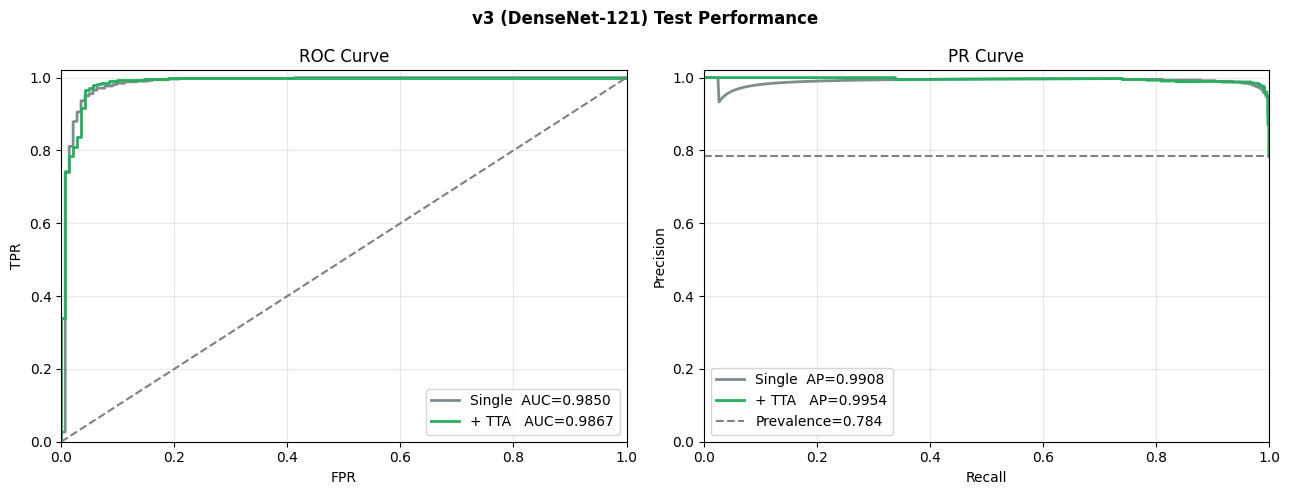

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("v3 (DenseNet-121) Test Performance",
             fontsize=12, fontweight="bold")

fpr_s, tpr_s, _ = roc_curve(ty_s, ts_s)
fpr_t, tpr_t, _ = roc_curve(ty_t, ts_t)
ax[0].plot(fpr_s, tpr_s, lw=2, color="#7f8c8d", label=f"Single  AUC={m_single['roc_auc']:.4f}")
ax[0].plot(fpr_t, tpr_t, lw=2, color="#27ae60", label=f"+ TTA   AUC={m_tta['roc_auc']:.4f}")
ax[0].plot([0,1],[0,1], "--", color="gray")
ax[0].set(xlim=(0,1), ylim=(0,1.02), xlabel="FPR", ylabel="TPR", title="ROC Curve")
ax[0].legend(loc="lower right"); ax[0].grid(alpha=0.3)

p_s, r_s, _ = precision_recall_curve(ty_s, ts_s)
p_t, r_t, _ = precision_recall_curve(ty_t, ts_t)
ax[1].plot(r_s, p_s, lw=2, color="#7f8c8d", label=f"Single  AP={m_single['pr_auc']:.4f}")
ax[1].plot(r_t, p_t, lw=2, color="#27ae60", label=f"+ TTA   AP={m_tta['pr_auc']:.4f}")
ax[1].axhline((ty_s==1).mean(), color="gray", ls="--",
              label=f"Prevalence={(ty_s==1).mean():.3f}")
ax[1].set(xlim=(0,1), ylim=(0,1.02), xlabel="Recall", ylabel="Precision", title="PR Curve")
ax[1].legend(loc="lower left"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 11 · Confusion Matrices

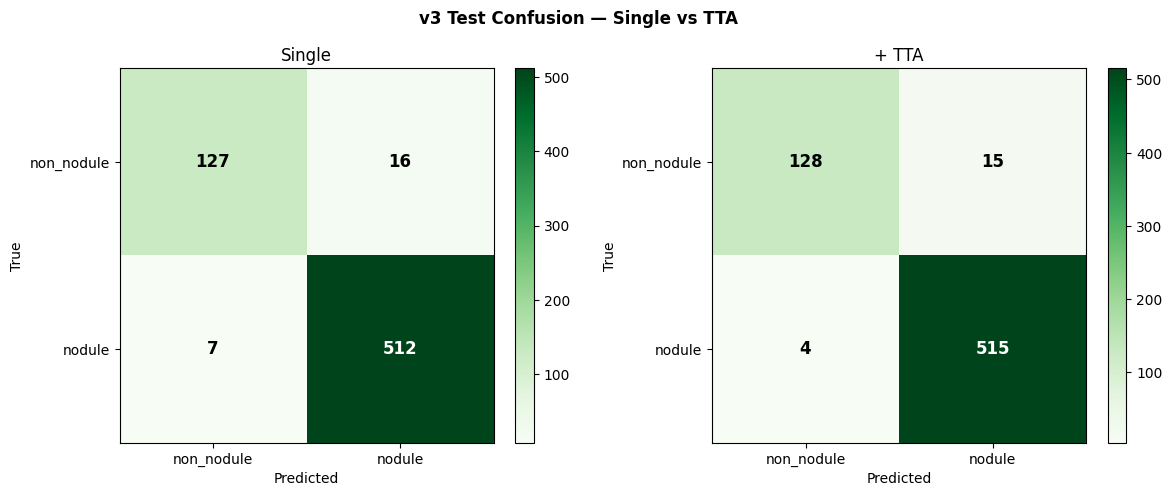

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("v3 Test Confusion — Single vs TTA", fontsize=12, fontweight="bold")
for a, m, ttl in [(ax[0], m_single, "Single"), (ax[1], m_tta, "+ TTA")]:
    cm = np.array([[m['confusion']['TN'], m['confusion']['FP']],
                   [m['confusion']['FN'], m['confusion']['TP']]])
    im = a.imshow(cm, cmap="Greens"); plt.colorbar(im, ax=a, fraction=0.046)
    a.set(xticks=range(2), yticks=range(2),
          xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
          xlabel="Predicted", ylabel="True", title=ttl)
    th = cm.max()/2
    for i in range(2):
        for j in range(2):
            a.text(j, i, cm[i,j], ha="center", va="center",
                   color="white" if cm[i,j]>th else "black", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


## 12 · Comparison vs v2 (TTA results)

In [12]:
# Load v2 metrics
v2_path = Path("luna16_output_v2/evaluation_report.json")
v2_metrics = None
if v2_path.exists():
    v2 = json.loads(v2_path.read_text())
    v2_metrics_single = v2.get("test_single_pass", {})
    v2_metrics_tta    = v2.get("test_tta", {})
else:
    print("v2 metrics not found.")

if v2_metrics_tta:
    rows = ["accuracy","balanced_acc","precision","recall","specificity",
            "f1","mcc","roc_auc","pr_auc"]
    print("="*88)
    print(f"  {'Metric':<18} {'v2 +TTA':>12} {'v3 single':>12} {'v3 +TTA':>12} {'Δ (v3 TTA - v2 TTA)':>22}")
    print("-"*88)
    for k in rows:
        a = v2_metrics_tta.get(k)
        b = m_single.get(k)
        c = m_tta.get(k)
        d = c - a
        sign = "+" if d>=0 else ""
        print(f"  {k:<18} {a:>12.4f} {b:>12.4f} {c:>12.4f} {sign}{d:>21.4f}")
    print("="*88)
    print(f"\n  v2 architecture: ResNet-50 + CBAM   (~24.0 M params)")
    print(f"  v3 architecture: DenseNet-121       ( ~8.0 M params)")

v3_report = {
    "dataset": "LUNA16 subsets 2+7-9 (patient-level split)",
    "model":   {"backbone": "densenet121", "best_epoch": int(ck["epoch"])},
    "loss":    f"FocalLoss(alpha={FOCAL_ALPHA}, gamma={FOCAL_GAMMA})",
    "augmentation": ["flip","rotate","color-jitter","random-erasing", f"mixup(alpha={MIXUP_ALPHA})"],
    "test_single_pass": m_single,
    "test_tta":         m_tta,
}
(OUT_DIR/"evaluation_report.json").write_text(json.dumps(v3_report, indent=2))
print(f"\nSaved {OUT_DIR}/evaluation_report.json")


  Metric                  v2 +TTA    v3 single      v3 +TTA    Δ (v3 TTA - v2 TTA)
----------------------------------------------------------------------------------------
  accuracy                 0.9653       0.9653       0.9713 +               0.0060
  balanced_acc             0.9474       0.9373       0.9437               -0.0037
  precision                0.9769       0.9697       0.9717               -0.0052
  recall                   0.9788       0.9865       0.9923 +               0.0135
  specificity              0.9161       0.8881       0.8951               -0.0210
  f1                       0.9779       0.9780       0.9819 +               0.0040
  mcc                      0.8972       0.8958       0.9140 +               0.0168
  roc_auc                  0.9852       0.9850       0.9867 +               0.0016
  pr_auc                   0.9949       0.9908       0.9954 +               0.0005

  v2 architecture: ResNet-50 + CBAM   (~24.0 M params)
  v3 architecture: DenseNet-

## 13 · Final Summary

In [13]:
print("="*70)
print("  LUNA16 v3 — FINAL TEST RESULTS (DenseNet-121)")
print("="*70)
print(f"  Architecture   : DenseNet-121  ({n_params:,} params)")
print(f"  Loss           : Focal Loss (α={FOCAL_ALPHA}, γ={FOCAL_GAMMA})")
print(f"  Augmentation   : flip / rotate / colour-jitter / erasing + MixUp(α={MIXUP_ALPHA})")
print(f"  Inference      : 5-view TTA")
print(f"  Train data     : subset2 + subset7  ({len(train_ds)} patches)")
print(f"  Best epoch     : {ck['epoch']}")
print("-"*70)
print(f"  Test metrics @ TTA (deployment configuration)")
print(f"    Accuracy        : {m_tta['accuracy']:.4f}")
print(f"    Balanced Acc    : {m_tta['balanced_acc']:.4f}")
print(f"    Precision       : {m_tta['precision']:.4f}")
print(f"    Recall          : {m_tta['recall']:.4f}")
print(f"    Specificity     : {m_tta['specificity']:.4f}")
print(f"    F1-Score        : {m_tta['f1']:.4f}")
print(f"    MCC             : {m_tta['mcc']:.4f}")
print(f"    ROC-AUC         : {m_tta['roc_auc']:.4f}")
print(f"    PR-AUC          : {m_tta['pr_auc']:.4f}")
print("="*70)


  LUNA16 v3 — FINAL TEST RESULTS (DenseNet-121)
  Architecture   : DenseNet-121  (6,957,954 params)
  Loss           : Focal Loss (α=0.25, γ=2.0)
  Augmentation   : flip / rotate / colour-jitter / erasing + MixUp(α=0.4)
  Inference      : 5-view TTA
  Train data     : subset2 + subset7  (1407 patches)
  Best epoch     : 23
----------------------------------------------------------------------
  Test metrics @ TTA (deployment configuration)
    Accuracy        : 0.9713
    Balanced Acc    : 0.9437
    Precision       : 0.9717
    Recall          : 0.9923
    Specificity     : 0.8951
    F1-Score        : 0.9819
    MCC             : 0.9140
    ROC-AUC         : 0.9867
    PR-AUC          : 0.9954
